<a href="https://colab.research.google.com/github/Ayesha-Raza786/AI_internship_tasks/blob/main/Task_2_NLP_Sentiment_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1086 entries, 0 to 1085
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   comments    1086 non-null   object
 1   sentiments  1086 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 17.1+ KB


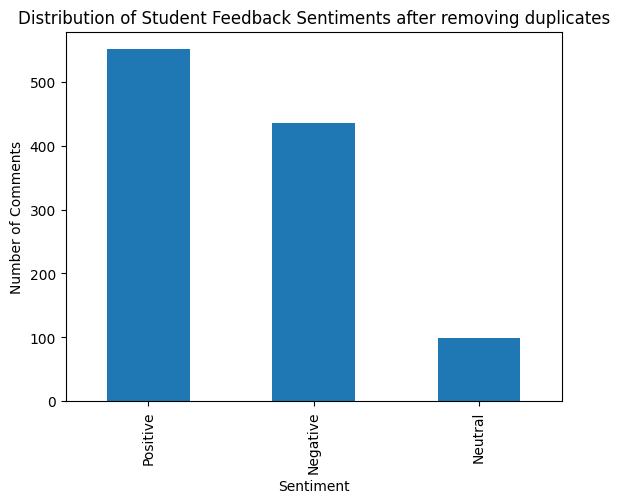

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


(1063,)
(1063,)
X_train_text: (850,)
X_test_text: (213,)
y_train: (850,)
y_test: (213,)
Actual:    [2 0 1 0 0 1 1 1 1 0 1 0 0 1 0 1 1 0 1 0]
Predicted: [0 2 0 0 0 1 0 0 0 1 0 0 0 1 1 1 2 0 1 1]
Accuracy: 0.7136150234741784
              precision    recall  f1-score   support

    Negative       0.69      0.73      0.71        83
    Positive       0.81      0.70      0.75       110
     Neutral       0.47      0.70      0.56        20

    accuracy                           0.71       213
   macro avg       0.66      0.71      0.67       213
weighted avg       0.73      0.71      0.72       213

[[61 15  7]
 [24 77  9]
 [ 3  3 14]]
306                            you are a strict teacher 
233    I've intrest in programming but I don't know t...
12                  why did not you play cricket with us
286    you make difficult paper. students with prepar...
386    time spent with you was marvellous and leant a...
928    student likes those teachers who have indepth ...
Name: comments, d

In [ ]:
import pandas as pd

df = pd.read_csv("/content/Student_Feedback.csv", encoding="latin1")

df.head()
df.info()
df.columns
#....................EDA.........................
df['sentiments'].value_counts()
df.head(20)
sentiment_mapping = {
    0: "Negative",
    1: "Positive",
    2: "Neutral"
}

df["sentiment_label"] = df["sentiments"].map(sentiment_mapping)

df.head()
df.shape

import matplotlib.pyplot as plt

df["sentiment_label"].value_counts().plot(kind="bar")

plt.title("Distribution of Student Feedback Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")

plt.show()
df.sample(10)
df[df["sentiment_label"] == "Positive"]["comments"].head(5)
df[df["sentiment_label"] == "Negative"]["comments"].head(5)
df[df["sentiment_label"] == "Neutral"]["comments"].head(5)
df.isnull().sum()

df.duplicated().sum()
df["comments"].duplicated().sum()

df["sentiment_label"].value_counts()

df["comment_length"] = df["comments"].str.len()

df[["comments", "comment_length"]].head()
df["comment_length"].describe()
# Complete duplicate rows
df.duplicated().sum()
# Repeated comments
df["comments"].duplicated().sum()
duplicates = df[df.duplicated(keep=False)]

duplicates.sort_values("comments")
df = df.drop_duplicates()
df.shape
df.duplicated().sum()
df["comments"].duplicated().sum()

df["sentiment_label"].value_counts().plot(kind="bar")

plt.title("Distribution of Student Feedback Sentiments after removing duplicates")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")

plt.show()
df.groupby("sentiment_label")["comments"].apply(lambda x: x.head(3))
# lowercase
df["cleaned_comments"] = df["comments"].str.lower()
suggestion_words = ["should", "could", "may", "must", "need to", "please", "kindly"]
df["has_suggestion_marker"] = df["comments"].str.lower().apply(
    lambda x: int(any(w in x for w in suggestion_words))
)
# then hstack this column onto  TF-IDF matrix (scipy.sparse.hstack)
df[["comments", "cleaned_comments"]].head(10)

# ...................NLP...........................
import nltk
nltk.download('punkt')

df["tokens"] = df["cleaned_comments"].apply(lambda text: text.split())

df[["cleaned_comments", "tokens"]].head(10)
from nltk.corpus import stopwords

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))
important_words = {"not", "no", "nor", "never"}

stop_words = stop_words - important_words

stop_words.add("us")
df["tokens_without_stopwords"] = df["tokens"].apply(
    lambda words: [word for word in words if word not in stop_words]
)

df[["tokens", "tokens_without_stopwords"]].head(10)
from nltk.stem import WordNetLemmatizer

nltk.download("wordnet")
nltk.download("omw-1.4")
lemmatizer = WordNetLemmatizer()
df["lemmatized_tokens"] = df["tokens_without_stopwords"].apply(
    lambda words: [lemmatizer.lemmatize(token) for token in words]
)

df[["tokens_without_stopwords", "lemmatized_tokens"]].head(10)
#  back to sentence form
df["processed_comments"] = df["lemmatized_tokens"].apply(
    lambda tokens: " ".join(tokens)
)
df[["comments", "processed_comments"]].head(10)
# .......................TF-IDF......................
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_initial = TfidfVectorizer() # Renamed to avoid conflict

X_text = df["processed_comments"]
y = df["sentiments"]
print(X_text.shape)
print(y.shape)
from sklearn.model_selection import train_test_split
marker = df["has_suggestion_marker"]

X_train_text, X_test_text, y_train, y_test, marker_train, marker_test = train_test_split(
    X_text, y, marker,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("X_train_text:", X_train_text.shape)
print("X_test_text:", X_test_text.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
from scipy.sparse import hstack
import numpy as np

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

# reshape marker to a column vector, then stack
X_train = hstack([X_train_tfidf, np.array(marker_train).reshape(-1, 1)])
X_test = hstack([X_test_tfidf, np.array(marker_test).reshape(-1, 1)])

#........... machine learning models.....................

# Logistic Regression with balanced class weights outperformed Naive Bayes, SVM, and SMOTE on 5-fold cross-validated macro F1
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    class_weight='balanced',

    max_iter=1000)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
y_pred[:10]
print("Actual:   ", y_test.values[:20])
print("Predicted:", y_pred[:20])
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive", "Neutral"]
))
from sklearn.metrics import confusion_matrix
import numpy as np
cm = confusion_matrix(y_test, y_pred)
print(cm)
neutral_mask = (y_test == 2)
wrong_mask = (y_pred != y_test) & neutral_mask
print(df.loc[y_test[wrong_mask].index, "comments"])
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro')
print(scores, scores.mean())